In [38]:
import numpy as np
import pandas as pd

In [39]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score,ConfusionMatrixDisplay, RocCurveDisplay

In [40]:
datas = load_breast_cancer()

In [41]:
X = pd.DataFrame(
    datas.data,
    columns = data.feature_names
)

In [42]:
y = datas.target

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
model = LogisticRegression(max_iter=1000)

In [46]:
model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [47]:
y_pred = model.predict(X_test_scaled)

In [48]:
Accuracy = accuracy_score(y_test,y_pred)
Precision = precision_score(y_test,y_pred)
Recall = recall_score(y_test,y_pred)
F1 = f1_score(y_test,y_pred)

In [49]:
print(round(Accuracy,4))

0.9737


In [50]:
print((round(Precision,4)))

0.9722


In [51]:
print((round(Recall,4)))

0.9859


In [52]:
print((round(F1,4)))

0.979


In [53]:
c_mt = confusion_matrix(y_test,y_pred)
print(c_mt)

[[41  2]
 [ 1 70]]


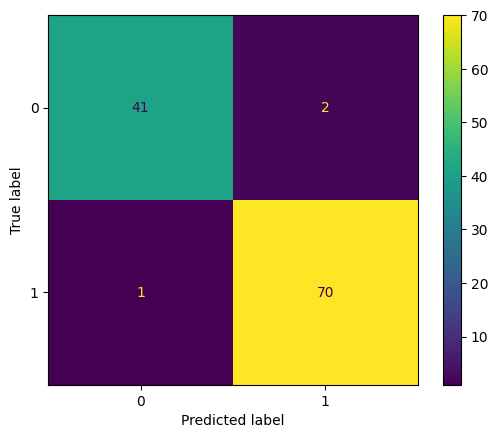

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [55]:
r_a = roc_auc_score(y_test,y_pred)
print(r_a)

0.969701932525385


In [59]:
y_prob = model.predict_proba(
    X_test_scaled
)[:, 1]


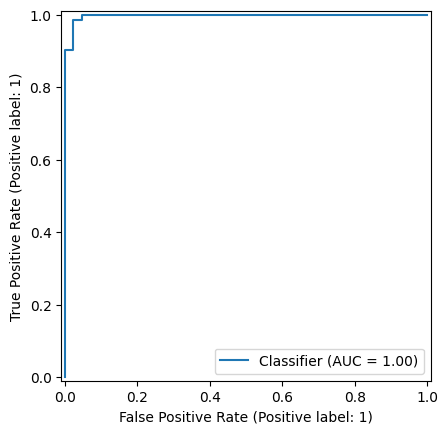

In [60]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

In [61]:
from sklearn.pipeline import Pipeline
model = Pipeline([
        ('scaler', StandardScaler()),
        ('Logistic',LogisticRegression(max_iter=1000))
    ])
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

In [62]:
cv_scores

array([0.99475925, 0.99672453, 0.99702381, 0.98776455, 0.99966465])

In [63]:
print(cv_scores.mean())

0.9951873601644319
